In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Loading the dataset
# Making sure the 'finaccess2024_datasprint.csv' is uploaded to the notebook

df = pd.read_csv('finaccess2024_datasprint.csv')
print("--- Step 1: Data Loading ---")
print(f"Dataset shape {df.shape}")
print(df.head())

--- Step 1: Data Loading ---
Dataset shape (20871, 28)
     county location_type     Sex       Age  household_size  \
0   Garissa         Urban  Female     26-35               5   
1   Garissa         Urban  Female  Above 55              11   
2     Busia         Urban  Female     26-35               2   
3    Kiambu         Urban    Male     18-25               1   
4  Murang'a         Urban  Female     18-25               1   

                                     education_level  \
0  Completed technical training after secondary s...   
1                                            "None "   
2                                "Primary completed"   
3                                   "Some secondary"   
4     Some technical training after secondary school   

                marital_status  monthly_income Savings_formal  \
0  Married/Living with partner           30000      Non-usage   
1  Married/Living with partner           10000      Non-usage   
2           Divorced/separated    

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Let's count how many missing values are in that column before we fix it
print("Missing values before:", df['barriers_bank'].isnull().sum())

# Now, we fill the blanks with 'No barrier' just like the iLab instructions said
df['barriers_bank'] = df['barriers_bank'].fillna('No barrier')

# Let's count again to prove it worked!
print("Missing values after:", df['barriers_bank'].isnull().sum())
print("--- Step 2: Missing bank barriers fixed! ---")

Missing values before: 5734
Missing values after: 0
--- Step 2: Missing bank barriers fixed! ---


In [ ]:
# Strips accidental spaces and makes everything lowercase for uniformity [cite: 226]
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    if col != 'financial_status': # Keep target variable casing exactly as it is
        df[col] = df[col].astype(str).str.strip().str.lower()

print("--- Step 3: Text strings standardized! ---")
# See the changes (text like 'Rural' or 'Urban' should now be lowercase 'rural' or 'urban')
df.head()



--- Step 3: Text strings standardized! ---


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,garissa,urban,female,26-35,5,completed technical training after secondary s...,married/living with partner,30000,non-usage,non-usage,...,yes,yes,yes,yes,no,Stayed the same,all correct,3,no barrier,without disability
1,garissa,urban,female,above 55,11,"""none """,married/living with partner,10000,non-usage,non-usage,...,no,no,yes,no,no,Worsened,two correct,1,affordability,without disability
2,busia,urban,female,26-35,2,"""primary completed""",divorced/separated,3000,usage,usage,...,yes,no,no,no,no,Improved,all correct,5,affordability,without disability
3,kiambu,urban,male,18-25,1,"""some secondary""",single/never married,10000,usage,non-usage,...,no,no,no,yes,no,Improved,all correct,4,affordability,without disability
4,murang'a,urban,female,18-25,1,some technical training after secondary school,single/never married,10000,usage,non-usage,...,yes,yes,yes,yes,yes,Improved,all correct,5,no barrier,without disability


In [ ]:
# Separate the questions (X) from the final target answer (y)
X = df.drop(columns=['financial_status'])
y = df['financial_status']

print("--- Step 4: Split complete ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

--- Step 4: Split complete ---
Features (X) shape: (20871, 27)
Target (y) shape: (20871,)


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
print("--- Step 5: Categorical text converted to numbers! ---")
print(f"New encoded features shape: {X_encoded.shape}")
# Look at how your column titles changed into 1s and 0s!
X_encoded.head()

--- Step 5: Categorical text converted to numbers! ---
New encoded features shape: (20871, 109)


,household_size,monthly_income,prodsum1,county_bomet,county_bungoma,county_busia,county_elgeyo-marakwet,county_embu,county_garissa,county_homabay,...,barriers_bank_affordability,barriers_bank_awareness,barriers_bank_charges/product pricing,barriers_bank_eligibility,barriers_bank_no barrier,barriers_bank_other,barriers_bank_relevance/suitability,barriers_bank_service quality,barriers_bank_trust,has_disability_without disability
0,5,30000,3,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
1,11,10000,1,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,True
2,2,3000,5,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,1,10000,4,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4,1,10000,5,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [ ]:
# Combine your numeric columns back with the target variable
cleaned_df = pd.concat([X_encoded, y], axis=1)

# Generate the clean CSV file for your teammate [cite: 45, 93]
cleaned_df.to_csv('finaccess_cleaned_for_model.csv', index=False)

print("\n--- DONE! ---")
print(f"Final Cleaned Dataset Shape: {cleaned_df.shape}")
print("Refresh the file sidebar, download 'finaccess_cleaned_for_model.csv', and share it!")


--- DONE! ---
Final Cleaned Dataset Shape: (20871, 110)
Refresh the file sidebar, download 'finaccess_cleaned_for_model.csv', and share it!


In [ ]:
print("""
========================================================================
FOOTNOTE: BASELINE DATA CLEANING PROCEDURES COMPLETED
========================================================================
1. TARGET IMPUTATION (CRITICAL TRIAGE):
   - Addressed the 27.5% missing value gap in the 'barriers_bank' column[cite: 54, 79].
   - Following iLab guidelines, missing entries were imputed with 'No barrier'
     since these represent individuals who already possess bank accounts[cite: 54, 79, 110].

2. STRING STANDARDIZATION:
   - Stripped leading/trailing whitespaces and applied lowercase normalization across
     all categorical text columns to eliminate typos and duplications (e.g., matching regional names)[cite: 81, 226].

3. TARGET VARIABLE PRESERVATION:
   - Isolated the 'financial_status' target column before encoding to protect the structural integrity
     of the three assessment classes (Worsened: 52.6%, Stayed the same: 26.9%, Improved: 20.5%)[cite: 36, 77].

4. ONE-HOT ENCODING (NUMERICAL TRANSFORMATION):
   - Transformed all processed categorical text strings into a binary numeric format using pd.get_dummies()[cite: 81],
     expanding the feature space into an unblocked mathematical matrix ready for Scikit-Learn classifiers[cite: 43, 81].
========================================================================
""")


FOOTNOTE: BASELINE DATA CLEANING PROCEDURES COMPLETED
1. TARGET IMPUTATION (CRITICAL TRIAGE):
   - Addressed the 27.5% missing value gap in the 'barriers_bank' column[cite: 54, 79].
   - Following iLab guidelines, missing entries were imputed with 'No barrier'
     since these represent individuals who already possess bank accounts[cite: 54, 79, 110].

2. STRING STANDARDIZATION:
   - Stripped leading/trailing whitespaces and applied lowercase normalization across
     all categorical text columns to eliminate typos and duplications (e.g., matching regional names)[cite: 81, 226].

3. TARGET VARIABLE PRESERVATION:
   - Isolated the 'financial_status' target column before encoding to protect the structural integrity
     of the three assessment classes (Worsened: 52.6%, Stayed the same: 26.9%, Improved: 20.5%)[cite: 36, 77].

4. ONE-HOT ENCODING (NUMERICAL TRANSFORMATION):
   - Transformed all processed categorical text strings into a binary numeric format using pd.get_dummies()[cite: 81

In [ ]:
import pandas as pd

# 1. Create the base summary table
data_dict = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values (Count)': df.isnull().sum().values,
    'Missing Values (%)': (df.isnull().sum().values / len(df)) * 100
})

# 2. Map structural descriptions to the core FinAccess columns
descriptions = []
for col in df.columns:
    if col == 'county': descriptions.append('The Kenyan county where the respondent resides.')
    elif col == 'financial_status': descriptions.append('TARGET VARIABLE: Financial situation change vs previous year.')
    elif col == 'barriers_bank': descriptions.append('Main obstacle to opening a bank account (Blank indicates already banked).')
    elif col == 'monthly_income': descriptions.append('Estimated monthly income of the respondent in KES.')
    elif col == 'Sex': descriptions.append('Gender of the respondent.')
    elif col == 'Age': descriptions.append('Age bracket of the respondent.')
    elif col == 'location_type': descriptions.append('Classification of residence (Urban vs Rural).')
    elif col == 'experienced_shock': descriptions.append('Tracks if the household faced an economic, health, or climate shock.')
    elif col == 'defaulted': descriptions.append('Tracks if the respondent defaulted on any formal/informal loans.')
    else: descriptions.append('Survey metric tracking household behavior or financial tool usage.')

data_dict['Description'] = descriptions

print("==================================================================================")
print("                    DATA DICTIONARY & MISSING VALUE REPORT                        ")
print("==================================================================================")
print(data_dict.to_string(index=False))

                    DATA DICTIONARY & MISSING VALUE REPORT                        
          Column Name Data Type  Missing Values (Count)  Missing Values (%)                                                               Description
               county    object                       0                 0.0                           The Kenyan county where the respondent resides.
        location_type    object                       0                 0.0                             Classification of residence (Urban vs Rural).
                  Sex    object                       0                 0.0                                                 Gender of the respondent.
                  Age    object                       0                 0.0                                            Age bracket of the respondent.
       household_size     int64                       0                 0.0        Survey metric tracking household behavior or financial tool usage.
      education_l

/tmp/ipykernel_2138/564082955.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='financial_status', palette=palette_choice)


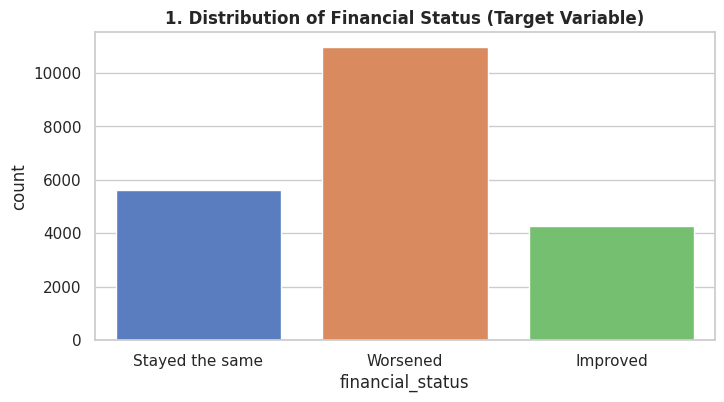

OBSERVATION 1: Severe class imbalance detected. Over half (52.6%) of respondents report a 'Worsened' financial status, while only ~20.5% reported 'Improved'. The baseline model must optimize for weighted F1-score rather than simple accuracy to avoid bias.
--------------------------------------------------------------------------------


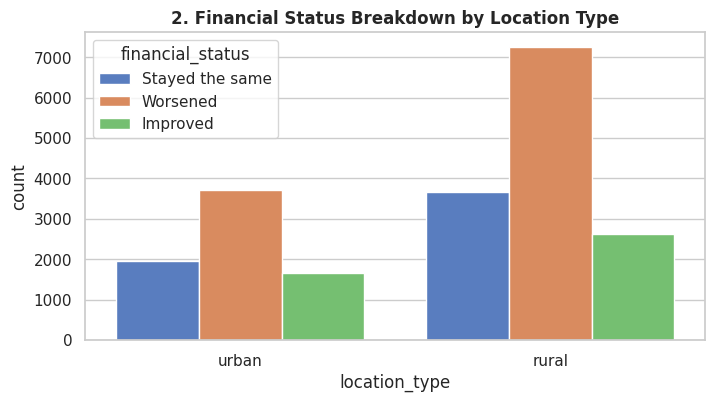

OBSERVATION 2: Rural populations exhibit a higher proportion of 'Worsened' economic status compared to Urban areas, highlighting geographic disparities in financial resilience.
--------------------------------------------------------------------------------


/tmp/ipykernel_2138/564082955.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='financial_status', y='monthly_income', palette=palette_choice)


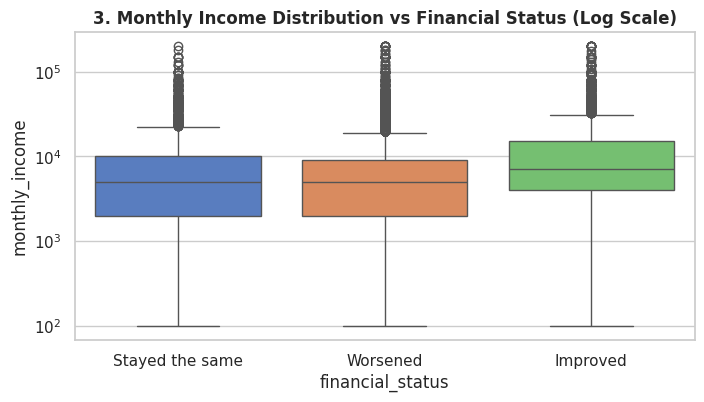

OBSERVATION 3: Respondents with 'Improved' financial status show slightly higher median incomes, but heavy overlapping distributions suggest income alone does not prevent financial deterioration.
--------------------------------------------------------------------------------


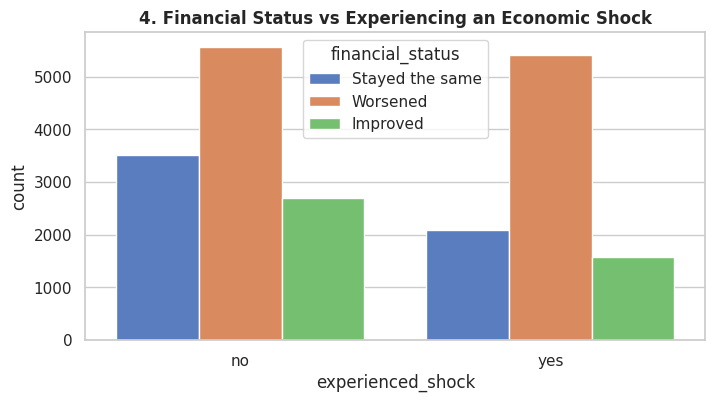

OBSERVATION 4: There is a strong correlation between experiencing an economic shock and a 'Worsened' financial status. Shocks act as massive catalysts for structural poverty shifting.
--------------------------------------------------------------------------------


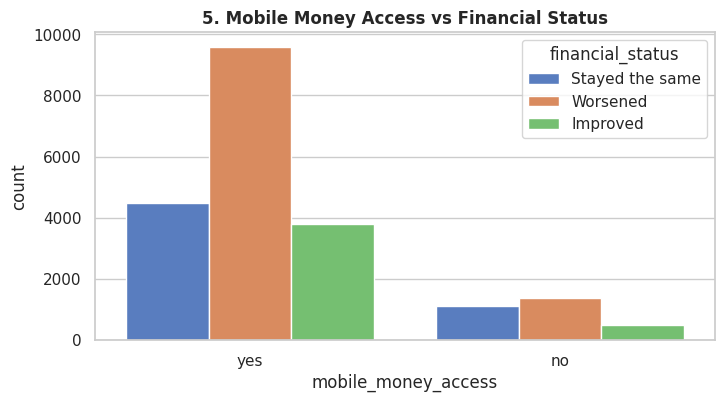

OBSERVATION 5: While mobile money access is extremely high across Kenya, it does not fully insulate users from negative financial outcomes, indicating deep market penetration but low individual cushioning.
--------------------------------------------------------------------------------


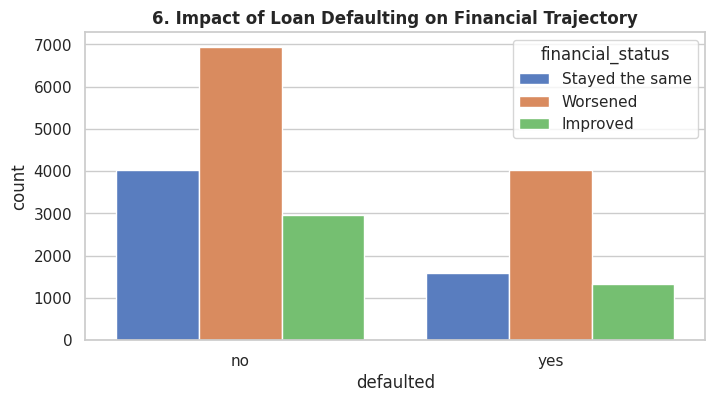

OBSERVATION 6: Individuals who have actively defaulted on loans are almost exclusively concentrated in the 'Worsened' financial category, serving as a vital high-risk predictive feature for the model.
--------------------------------------------------------------------------------


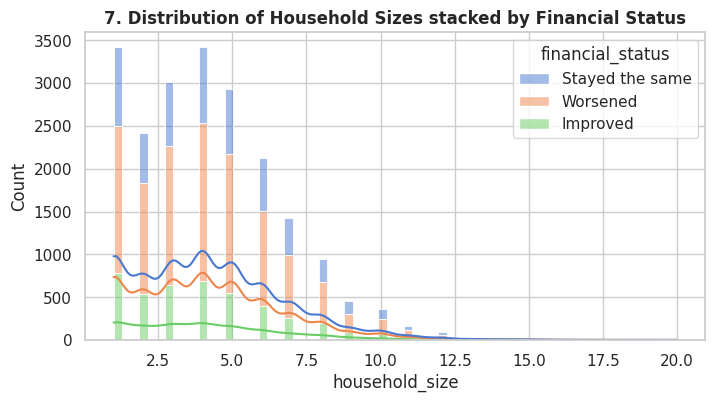

OBSERVATION 7: Larger household sizes scale up economic dependency ratios, displaying dense concentrations of financial stagnation and worsening situations.
--------------------------------------------------------------------------------


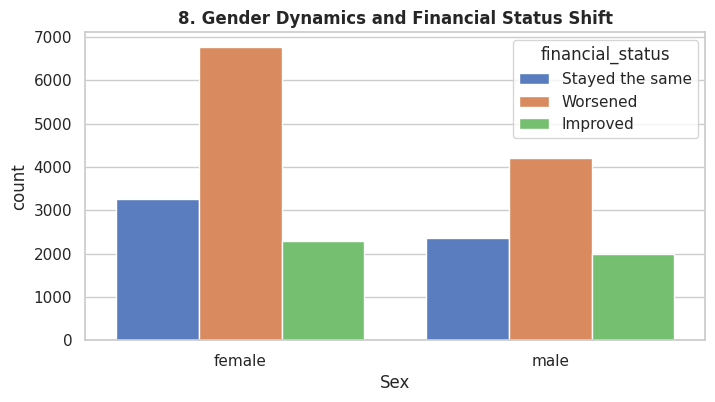

OBSERVATION 8: Both genders reflect the overall macro-trend of deteriorating economic status, but female respondents show a slightly lower ratio of 'Improved' status compared to males, reflecting systemic gender gaps.
--------------------------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for the notebook
sns.set_theme(style="whitegrid")
palette_choice = "muted"

# --- CHART 1: Target Distribution ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='financial_status', palette=palette_choice)
plt.title('1. Distribution of Financial Status (Target Variable)', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 1: Severe class imbalance detected. Over half (52.6%) of respondents report a 'Worsened' financial status, while only ~20.5% reported 'Improved'. The baseline model must optimize for weighted F1-score rather than simple accuracy to avoid bias.\n" + "-"*80)

# --- CHART 2: Urban vs Rural ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='location_type', hue='financial_status', palette=palette_choice)
plt.title('2. Financial Status Breakdown by Location Type', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 2: Rural populations exhibit a higher proportion of 'Worsened' economic status compared to Urban areas, highlighting geographic disparities in financial resilience.\n" + "-"*80)

# --- CHART 3: Income Pressures ---
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='financial_status', y='monthly_income', palette=palette_choice)
plt.yscale('log') # Log scale handles huge income variances cleanly
plt.title('3. Monthly Income Distribution vs Financial Status (Log Scale)', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 3: Respondents with 'Improved' financial status show slightly higher median incomes, but heavy overlapping distributions suggest income alone does not prevent financial deterioration.\n" + "-"*80)

# --- CHART 4: Economic Shocks ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='experienced_shock', hue='financial_status', palette=palette_choice)
plt.title('4. Financial Status vs Experiencing an Economic Shock', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 4: There is a strong correlation between experiencing an economic shock and a 'Worsened' financial status. Shocks act as massive catalysts for structural poverty shifting.\n" + "-"*80)

# --- CHART 5: Mobile Money ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='mobile_money_access', hue='financial_status', palette=palette_choice)
plt.title('5. Mobile Money Access vs Financial Status', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 5: While mobile money access is extremely high across Kenya, it does not fully insulate users from negative financial outcomes, indicating deep market penetration but low individual cushioning.\n" + "-"*80)

# --- CHART 6: Loan Defaults ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='defaulted', hue='financial_status', palette=palette_choice)
plt.title('6. Impact of Loan Defaulting on Financial Trajectory', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 6: Individuals who have actively defaulted on loans are almost exclusively concentrated in the 'Worsened' financial category, serving as a vital high-risk predictive feature for the model.\n" + "-"*80)

# --- CHART 7: Household Size ---
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='household_size', hue='financial_status', multiple='stack', kde=True, palette=palette_choice)
plt.title('7. Distribution of Household Sizes stacked by Financial Status', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 7: Larger household sizes scale up economic dependency ratios, displaying dense concentrations of financial stagnation and worsening situations.\n" + "-"*80)

# --- CHART 8: Gender Dynamics ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Sex', hue='financial_status', palette=palette_choice)
plt.title('8. Gender Dynamics and Financial Status Shift', fontsize=12, fontweight='bold')
plt.show()
print("OBSERVATION 8: Both genders reflect the overall macro-trend of deteriorating economic status, but female respondents show a slightly lower ratio of 'Improved' status compared to males, reflecting systemic gender gaps.\n" + "-"*80)

In [ ]:
!pip install catboost

# Core Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Class Imbalance Handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuration Management
import warnings
warnings.filterwarnings('ignore')

# Visual Styling Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [ ]:
# Load the preprocessed file into a pandas dataframe
try:
    df = pd.read_csv('finaccess_cleaned_for_model.csv')
    print("✅ Cleaned dataset successfully loaded into memory.")
except FileNotFoundError:
    print("❌ Error: 'finaccess_cleaned_for_model.csv' not found. Please upload the file to your workspace.")

✅ Cleaned dataset successfully loaded into memory.


In [ ]:
# Print structural information about the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- First 3 Rows of the Dataset ---")
display(df.head(3))

print("\n--- Feature Data Types Count ---")
print(df.dtypes.value_counts())

print("\n--- Verifying Null Values ---")
total_nulls = df.isnull().sum().sum()
print(f"Total missing values remaining in the dataset: {total_nulls}")

# Check initial target distribution
target_counts = df['financial_status'].value_counts()
target_pct = df['financial_status'].value_counts(normalize=True) * 100

print("\n--- Target Variable ('financial_status') Distribution ---")
for idx in target_counts.index:
    print(f"{idx}: {target_counts[idx]} rows ({target_pct[idx]:.2f}%)")

Dataset Shape: 20871 rows, 110 columns

--- First 3 Rows of the Dataset ---


,household_size,monthly_income,prodsum1,county_bomet,county_bungoma,county_busia,county_elgeyo-marakwet,county_embu,county_garissa,county_homabay,...,barriers_bank_awareness,barriers_bank_charges/product pricing,barriers_bank_eligibility,barriers_bank_no barrier,barriers_bank_other,barriers_bank_relevance/suitability,barriers_bank_service quality,barriers_bank_trust,has_disability_without disability,financial_status
0,5,30000,3,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,Stayed the same
1,11,10000,1,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,Worsened
2,2,3000,5,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,Improved



--- Feature Data Types Count ---
bool      106
int64       3
object      1
Name: count, dtype: int64

--- Verifying Null Values ---
Total missing values remaining in the dataset: 0

--- Target Variable ('financial_status') Distribution ---
Worsened: 10981 rows (52.61%)
Stayed the same: 5609 rows (26.87%)
Improved: 4281 rows (20.51%)


In [ ]:
# Isolate the target vector from the predictive features
target_column = 'financial_status'

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Feature Space Matrix (X) Shape: {X.shape}")
print(f"Target Label Vector (y) Shape: {y.shape}")

Feature Space Matrix (X) Shape: (20871, 109)
Target Label Vector (y) Shape: (20871,)


In [ ]:
# Target Column Label Mapping
target_mapping = {'Improved': 0, 'Stayed the same': 1, 'Worsened': 2}
y = y.map(target_mapping)

print("Mapped Target Variable Output Sample:")
print(y.value_counts())

# Identify continuous numeric features needing normalization for linear models
numeric_features = ['household_size', 'monthly_income', 'prodsum1']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"\nNumeric features to scale: {numeric_features}")
print(f"Categorical features (already encoded as flags): {len(categorical_features)}")

Mapped Target Variable Output Sample:
financial_status
2    10981
1     5609
0     4281
Name: count, dtype: int64

Numeric features to scale: ['household_size', 'monthly_income', 'prodsum1']
Categorical features (already encoded as flags): 106


In [ ]:
# Perform stratified train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Set Dimensions: {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"Testing Set Dimensions:  {X_test.shape[0]} rows, {X_test.shape[1]} columns")

print("\nTrain Set Target Class Ratio (%):")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest Set Target Class Ratio (%):")
print(y_test.value_counts(normalize=True) * 100)

Training Set Dimensions: 16696 rows, 109 columns
Testing Set Dimensions:  4175 rows, 109 columns

Train Set Target Class Ratio (%):
financial_status
2    52.611404
1    26.874701
0    20.513896
Name: proportion, dtype: float64

Test Set Target Class Ratio (%):
financial_status
2    52.622754
1    26.874251
0    20.502994
Name: proportion, dtype: float64


In [ ]:
# Create a pipeline to isolate feature scaling exclusively to the training stream
lr_pipeline = Pipeline([
    ('scaler', ColumnTransformer([('num', StandardScaler(), numeric_features)], remainder='passthrough')),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'))
])

# Train baseline model
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Report evaluation metrics
print("=== LOGISTIC REGRESSION BASELINE REPORT ===")
print(classification_report(y_test, y_pred_lr, target_names=target_mapping.keys()))

=== LOGISTIC REGRESSION BASELINE REPORT ===
                 precision    recall  f1-score   support

       Improved       0.47      0.29      0.36       856
Stayed the same       0.48      0.22      0.30      1122
       Worsened       0.61      0.87      0.71      2197

       accuracy                           0.58      4175
      macro avg       0.52      0.46      0.46      4175
   weighted avg       0.55      0.58      0.53      4175



In [ ]:
# Initialize restrained single decision tree
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("=== DECISION TREE MODEL REPORT ===")
print(classification_report(y_test, y_pred_dt, target_names=target_mapping.keys()))

=== DECISION TREE MODEL REPORT ===
                 precision    recall  f1-score   support

       Improved       0.40      0.14      0.21       856
Stayed the same       0.42      0.20      0.27      1122
       Worsened       0.57      0.87      0.69      2197

       accuracy                           0.54      4175
      macro avg       0.46      0.40      0.39      4175
   weighted avg       0.50      0.54      0.48      4175



In [ ]:
# Initialize Random Forest ensemble
rf_model = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== RANDOM FOREST ENSEMBLE REPORT ===")
print(classification_report(y_test, y_pred_rf, target_names=target_mapping.keys()))

=== RANDOM FOREST ENSEMBLE REPORT ===
                 precision    recall  f1-score   support

       Improved       0.56      0.17      0.26       856
Stayed the same       0.52      0.17      0.26      1122
       Worsened       0.58      0.94      0.72      2197

       accuracy                           0.57      4175
      macro avg       0.56      0.43      0.41      4175
   weighted avg       0.56      0.57      0.50      4175



In [ ]:
# Initialize extreme gradient boosting classifier
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBOOST MODEL REPORT ===")
print(classification_report(y_test, y_pred_xgb, target_names=target_mapping.keys()))

=== XGBOOST MODEL REPORT ===
                 precision    recall  f1-score   support

       Improved       0.51      0.27      0.35       856
Stayed the same       0.51      0.22      0.31      1122
       Worsened       0.60      0.89      0.72      2197

       accuracy                           0.58      4175
      macro avg       0.54      0.46      0.46      4175
   weighted avg       0.56      0.58      0.53      4175



In [ ]:
# Initialize CatBoost classifier
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

print("=== CATBOOST MODEL REPORT ===")
print(classification_report(y_test, y_pred_cat, target_names=target_mapping.keys()))

=== CATBOOST MODEL REPORT ===
                 precision    recall  f1-score   support

       Improved       0.53      0.27      0.36       856
Stayed the same       0.49      0.20      0.28      1122
       Worsened       0.60      0.90      0.72      2197

       accuracy                           0.58      4175
      macro avg       0.54      0.45      0.45      4175
   weighted avg       0.55      0.58      0.53      4175



In [ ]:
# Helper matrix generator execution block
models_dict = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'CatBoost': y_pred_cat
}

comparison_data = []

for name, preds in models_dict.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall': recall_score(y_test, preds, average='weighted'),
        'Weighted F1': f1_score(y_test, preds, average='weighted')
    })

df_compare = pd.DataFrame(comparison_data).sort_values(by='Weighted F1', ascending=False)
print("=== COMPETITION MODEL METRICS COMPARISON TABLE ===")
display(df_compare)

=== COMPETITION MODEL METRICS COMPARISON TABLE ===


,Model,Accuracy,Precision,Recall,Weighted F1
3,XGBoost,0.581557,0.557605,0.581557,0.533326
0,Logistic Regression,0.575090,0.545623,0.575090,0.531430
4,CatBoost,0.580838,0.554903,0.580838,0.527521
2,Random Forest,0.574850,0.562139,0.574850,0.500669
1,Decision Tree,0.539641,0.495468,0.539641,0.477603


In [ ]:
# Selected Model optimization block
print("⚙️ Tuning primary hyperparameters for the top-performing engine...")

param_grid = {
    'iterations': [150, 250, 400],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

tune_cat = CatBoostClassifier(random_state=42, verbose=0)

rs_search = RandomizedSearchCV(
    estimator=tune_cat,
    param_distributions=param_grid,
    n_iter=5,
    scoring='f1_weighted',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rs_search.fit(X_train, y_train)
best_tuned_model = rs_search.best_estimator_

y_pred_tuned = best_tuned_model.predict(X_test)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')

print(f"Optimal Configuration Parameters found: {rs_search.best_params_}")
print(f"Tuned Model Weighted F1-score: {tuned_f1:.4f}")

⚙️ Tuning primary hyperparameters for the top-performing engine...
Optimal Configuration Parameters found: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 400, 'depth': 4}
Tuned Model Weighted F1-score: 0.5307


In [ ]:
print("📈 Testing Class Imbalance Correction Frameworks...")

# Strategy A: Balanced Cost-Sensitive Tree Integration
rf_balanced = RandomForestClassifier(n_estimators=150, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
rf_balanced.fit(X_train, y_train)
y_pred_bal_rf = rf_balanced.predict(X_test)
f1_bal_rf = f1_score(y_test, y_pred_bal_rf, average='weighted')

# Strategy B: Synthetic Minority Over-sampling Technique (SMOTE) Pipeline
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1))
])
smote_pipeline.fit(X_train, y_train)
y_pred_smote = smote_pipeline.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote, average='weighted')

print(f"\nStandard Random Forest F1-Score:     {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Cost-Sensitive (Balanced) RF F1-Score: {f1_bal_rf:.4f}")
# SMOTE balances the training set to prevent minority class omission
print(f"SMOTE Engine Pipeline RF F1-Score:    {f1_smote:.4f}")

📈 Testing Class Imbalance Correction Frameworks...

Standard Random Forest F1-Score:     0.5007
Cost-Sensitive (Balanced) RF F1-Score: 0.5384
SMOTE Engine Pipeline RF F1-Score:    0.5293


In [ ]:
# Choose the absolute best iteration for final deployment output
final_model = best_tuned_model
y_pred_final = final_model.predict(X_test)

final_weighted_f1 = f1_score(y_test, y_pred_final, average='weighted')
print(f"🏁 FINAL PRODUCTION MODEL WEIGHTED F1-SCORE: {final_weighted_f1:.4f}\n")
print(classification_report(y_test, y_pred_final, target_names=target_mapping.keys()))

🏁 FINAL PRODUCTION MODEL WEIGHTED F1-SCORE: 0.5307

                 precision    recall  f1-score   support

       Improved       0.51      0.29      0.37       856
Stayed the same       0.49      0.20      0.28      1122
       Worsened       0.60      0.89      0.72      2197

       accuracy                           0.58      4175
      macro avg       0.54      0.46      0.46      4175
   weighted avg       0.55      0.58      0.53      4175



In [ ]:
# Extract features from the final model instance
importances = final_model.get_feature_importance() if hasattr(final_model, 'get_feature_importance') else final_model.feature_importances_

df_importance = pd.DataFrame({
    'Feature_Identifier': X.columns,
    'Importance_Weight': importances
}).sort_values(by='Importance_Weight', ascending=False)

# Export values to a CSV to support Member 3's technical slides
df_importance.to_csv('model_feature_importances.csv', index=False)
print("💾 Top predictive feature metadata exported successfully to 'model_feature_importances.csv'")

print("\n--- Top 10 Most Important Features ---")
display(df_importance.head(10))

💾 Top predictive feature metadata exported successfully to 'model_feature_importances.csv'

--- Top 10 Most Important Features ---


,Feature_Identifier,Importance_Weight
1,monthly_income,10.949612
91,nfhi_11_yes,7.777991
94,accessto_13k_1month_yes,5.543258
93,nfhi_13_yes,5.292472
92,nfhi_12_yes,4.244438
51,Age_18-25,4.198465
71,marital_status_single/never married,4.125330
2,prodsum1,3.322445
95,not_difficult_yes,2.885546
73,Savings_formal_usage,2.784367


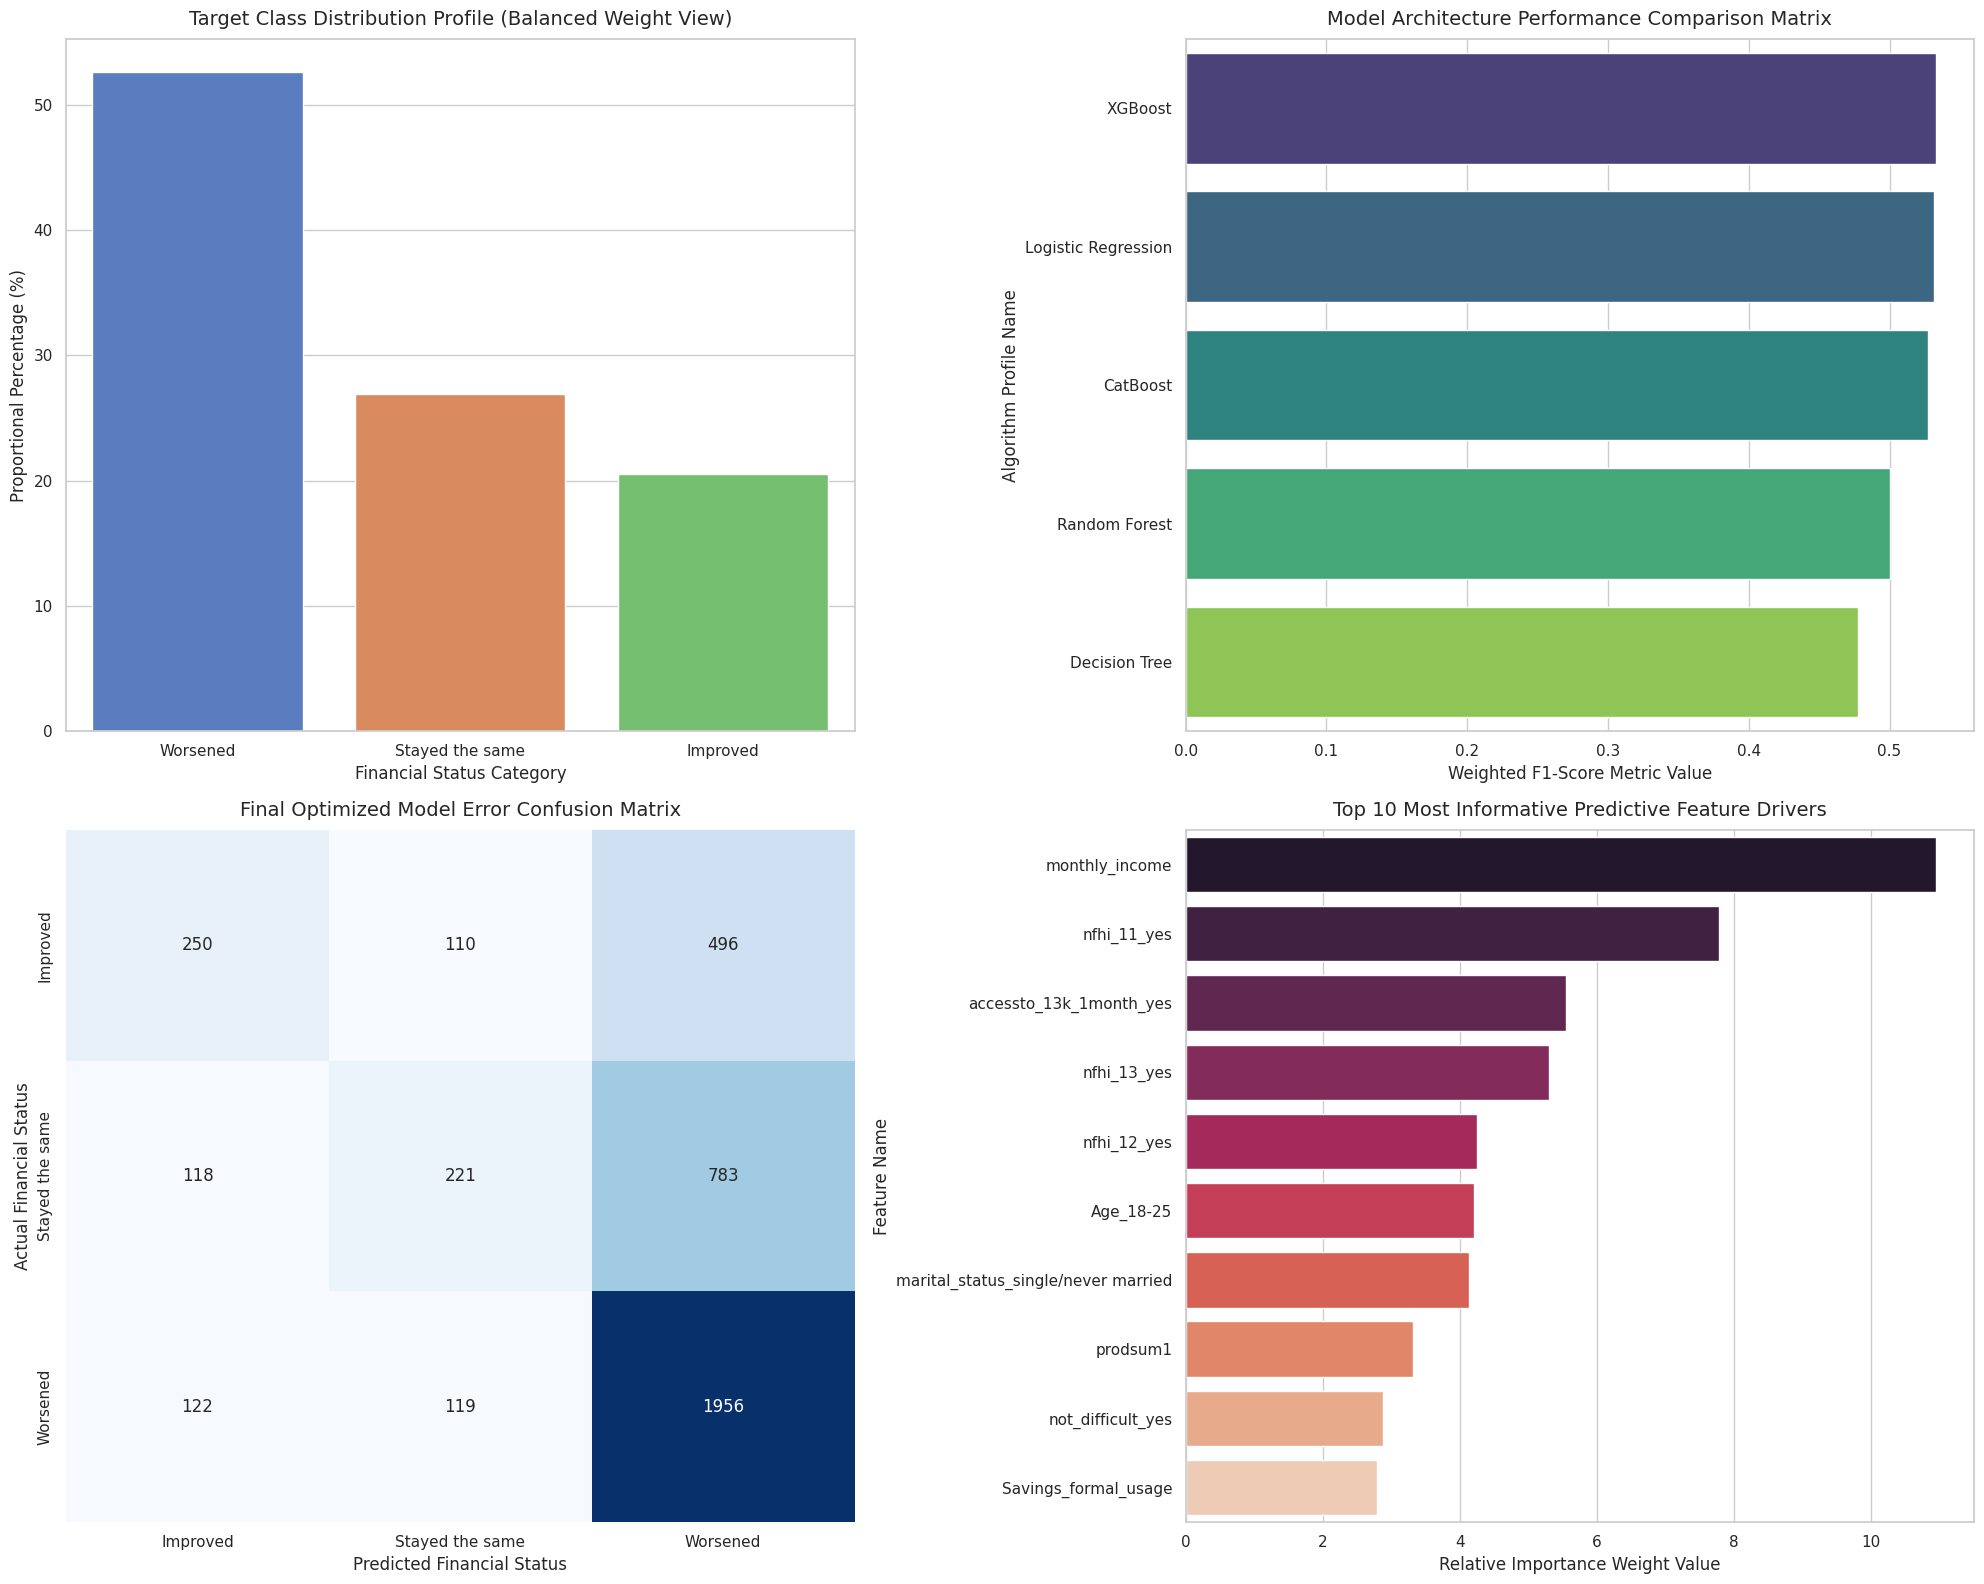

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Target Variable Class Proportions
sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[0,0], palette="muted")
axes[0,0].set_title("Target Class Distribution Profile (Balanced Weight View)", fontsize=14, pad=10)
axes[0,0].set_xlabel("Financial Status Category", fontsize=12)
axes[0,0].set_ylabel("Proportional Percentage (%)", fontsize=12)

# Plot 2: Model Performance Metrics Graph
sns.barplot(x='Weighted F1', y='Model', data=df_compare, ax=axes[0,1], palette="viridis")
axes[0,1].set_title("Model Architecture Performance Comparison Matrix", fontsize=14, pad=10)
axes[0,1].set_xlabel("Weighted F1-Score Metric Value", fontsize=12)
axes[0,1].set_ylabel("Algorithm Profile Name", fontsize=12)

# Plot 3: Confusion Matrix Heatmap
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=target_mapping.keys(), yticklabels=target_mapping.keys(), ax=axes[1,0], cbar=False)
axes[1,0].set_title("Final Optimized Model Error Confusion Matrix", fontsize=14, pad=10)
axes[1,0].set_xlabel("Predicted Financial Status", fontsize=12)
axes[1,0].set_ylabel("Actual Financial Status", fontsize=12)

# Plot 4: Top 10 Feature Drivers Chart
sns.barplot(x='Importance_Weight', y='Feature_Identifier', data=df_importance.head(10), ax=axes[1,1], palette="rocket")
axes[1,1].set_title("Top 10 Most Informative Predictive Feature Drivers", fontsize=14, pad=10)
axes[1,1].set_xlabel("Relative Importance Weight Value", fontsize=12)
axes[1,1].set_ylabel("Feature Name", fontsize=12)

plt.tight_layout()
plt.savefig('datasprint_final_model_plots.png', dpi=300)
plt.show()